In [34]:
import pandas as pd
import numpy as np

DATA_RAW = '../data/household_power_consumption.txt'
df = pd.read_csv(DATA_RAW, sep=';', low_memory=False)

pd.set_option('display.precision', 2)  

### Viewing the data 

In [35]:
df.sample(10)

,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
597049,4/2/2008,08:13:00,3.484,0.052,236.720,14.600,37.000,0.000,17.0
1558438,2/12/2009,23:22:00,0.718,0.124,242.670,3.000,0.000,0.000,1.0
637439,3/3/2008,09:23:00,0.578,0.068,239.350,2.400,0.000,0.000,0.0
843630,24/7/2008,13:54:00,0.268,0.000,241.030,1.000,0.000,0.000,1.0
218025,17/5/2007,03:09:00,0.388,0.200,236.450,1.800,0.000,0.000,0.0
1057385,20/12/2008,00:29:00,0.228,0.000,247.610,1.000,0.000,0.000,0.0
400889,21/9/2007,02:53:00,0.188,0.074,240.540,0.800,0.000,0.000,0.0
981504,28/10/2008,07:48:00,0.284,0.066,241.730,1.200,0.000,1.000,0.0
1374791,28/7/2009,10:35:00,0.556,0.248,241.280,2.400,0.000,2.000,0.0
524649,16/12/2007,01:33:00,1.274,0.046,242.560,5.200,0.000,0.000,0.0


Noticed that there are apparently extreme values in global intensity, sub_metering 1 and 2 columns

### Checking for missing values

In [36]:
# checking for missing values
df.isnull().sum()

Date                         0
Time                         0
Global_active_power          0
Global_reactive_power        0
Voltage                      0
Global_intensity             0
Sub_metering_1               0
Sub_metering_2               0
Sub_metering_3           25979
dtype: int64

In [37]:
df[df['Sub_metering_3'].isnull()].sample(10)

,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
1988588,27/9/2010,16:32:00,?,?,?,?,?,?,NaN
1936234,22/8/2010,07:58:00,?,?,?,?,?,?,NaN
1714099,21/3/2010,01:43:00,?,?,?,?,?,?,NaN
1617329,12/1/2010,20:53:00,?,?,?,?,?,?,NaN
1398213,13/8/2009,16:57:00,?,?,?,?,?,?,NaN
1618590,13/1/2010,17:54:00,?,?,?,?,?,?,NaN
1933138,20/8/2010,04:22:00,?,?,?,?,?,?,NaN
193485,30/4/2007,02:09:00,?,?,?,?,?,?,NaN
1987169,26/9/2010,16:53:00,?,?,?,?,?,?,NaN
1931347,18/8/2010,22:31:00,?,?,?,?,?,?,NaN


In [38]:
missing_rows = (df[df['Sub_metering_3'].isnull()].shape[0] / df.shape[0]) * 100
print(f'Percentage of corrupt rows: {missing_rows:.2f}%')

Percentage of corrupt rows: 1.25%


It is discovered that entries which have a NaN submetering_3 values also have most other columns as '?' 
These corrupt entries constitute 1.25% of the entire dataset

In [39]:
df.replace('?', np.nan, inplace=True)
df[df['Sub_metering_3'].isnull()].sample(10)

,Date,Time,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
194023,30/4/2007,11:07:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1714147,21/3/2010,02:31:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1988422,27/9/2010,13:46:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1397611,13/8/2009,06:55:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1619615,14/1/2010,10:59:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN
191598,28/4/2007,18:42:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1932002,19/8/2010,09:26:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN
190684,28/4/2007,03:28:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1618528,13/1/2010,16:52:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1930461,18/8/2010,07:45:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Metadata


In [40]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2075259 entries, 0 to 2075258
Data columns (total 9 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   Date                   str    
 1   Time                   str    
 2   Global_active_power    str    
 3   Global_reactive_power  str    
 4   Voltage                str    
 5   Global_intensity       str    
 6   Sub_metering_1         str    
 7   Sub_metering_2         str    
 8   Sub_metering_3         float64
dtypes: float64(1), str(8)
memory usage: 142.5 MB


Issues noticed: 
most of the columns are in wrong datatype
The date and time columns should be merged into a column datetime

In [41]:
cols_to_convert = ['Global_active_power', 'Global_reactive_power', 'Voltage',
                   'Global_intensity', 'Sub_metering_1', 'Sub_metering_2', 'Sub_metering_3']
df[cols_to_convert] = df[cols_to_convert].astype(float)

In [42]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2075259 entries, 0 to 2075258
Data columns (total 9 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   Date                   str    
 1   Time                   str    
 2   Global_active_power    float64
 3   Global_reactive_power  float64
 4   Voltage                float64
 5   Global_intensity       float64
 6   Sub_metering_1         float64
 7   Sub_metering_2         float64
 8   Sub_metering_3         float64
dtypes: float64(7), str(2)
memory usage: 142.5 MB


### Statistics on the dataset

In [43]:
df.describe()

,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
count,2.05e+06,2.05e+06,2.05e+06,2.05e+06,2.05e+06,2.05e+06,2.05e+06
mean,1.09e+00,1.24e-01,2.41e+02,4.63e+00,1.12e+00,1.30e+00,6.46e+00
std,1.06e+00,1.13e-01,3.24e+00,4.44e+00,6.15e+00,5.82e+00,8.44e+00
min,7.60e-02,0.00e+00,2.23e+02,2.00e-01,0.00e+00,0.00e+00,0.00e+00
25%,3.08e-01,4.80e-02,2.39e+02,1.40e+00,0.00e+00,0.00e+00,0.00e+00
50%,6.02e-01,1.00e-01,2.41e+02,2.60e+00,0.00e+00,0.00e+00,1.00e+00
75%,1.53e+00,1.94e-01,2.43e+02,6.40e+00,0.00e+00,1.00e+00,1.70e+01
max,1.11e+01,1.39e+00,2.54e+02,4.84e+01,8.80e+01,8.00e+01,3.10e+01


It seems that the target column has outliers because the target column - Global_active_power has a mean 1.09e+00 and a median of 6.02e+01

### Outlier detection


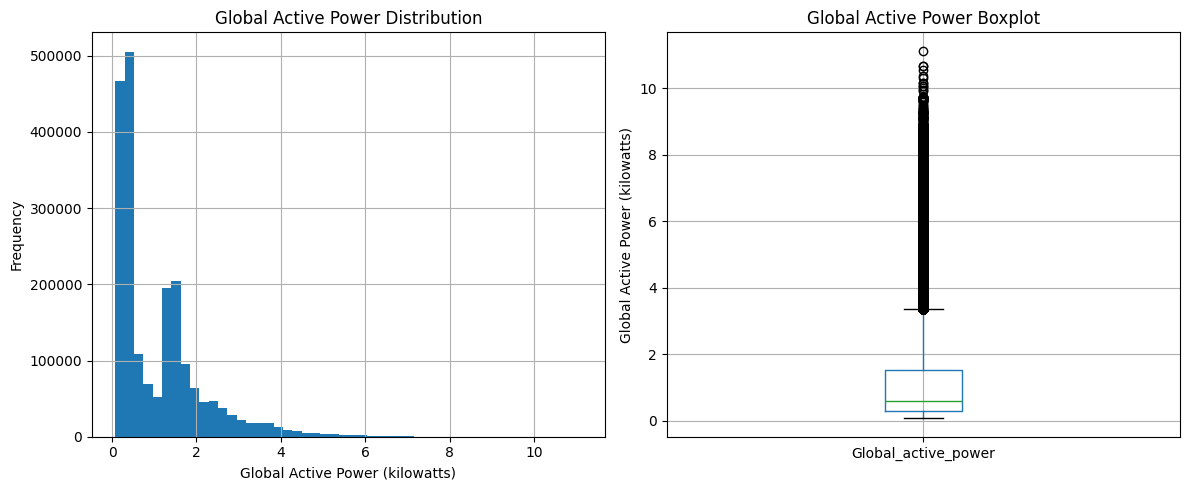

In [44]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

df['Global_active_power'].hist(bins=50, ax=axes[0])
axes[0].set_title('Global Active Power Distribution')
axes[0].set_xlabel('Global Active Power (kilowatts)')
axes[0].set_ylabel('Frequency')

df.boxplot(column='Global_active_power', ax=axes[1])
axes[1].set_title('Global Active Power Boxplot')
axes[1].set_ylabel('Global Active Power (kilowatts)')       

plt.tight_layout()
plt.show()

It is noticed that outliers in the target column are between ~3.5 up to 11 kilowatts 

### Varibles relation

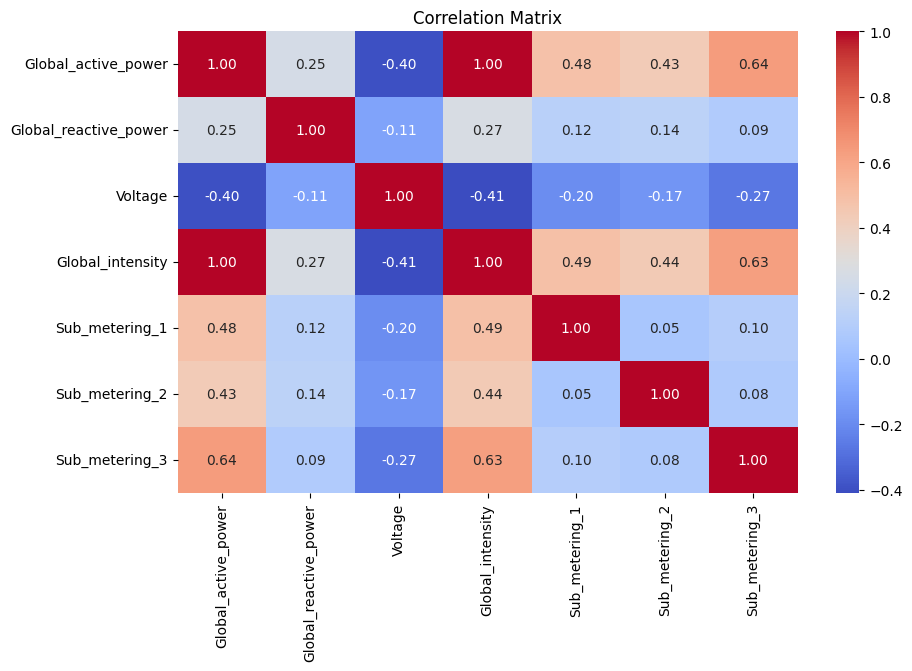

In [45]:
import seaborn as sns

corr = df.corr(numeric_only=True)

plt.figure(figsize=(10, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix')
plt.show()

It seems global_intensity has a perfect correlation with global_active_power, consider dropping that column to avoid redundacy 

In [46]:
df.to_csv('../data/household_power_consumption_eda.csv', index=False)